# Data Visualizations

In [1]:
# import packages 
import numpy as np
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

In [2]:
# colors 

'#f5f0e8'   # body-bg, hero bg, conclusion text, back-btn hover area
'#1a1a1a'   # body-color, hero h1, narrative-block text, conclusion bg, picker-btn active border
'#320b8d'   # link-color, kicker, artist-a accent, border-left on narrative-block, back-btn text
'#06395b'   # artist-b accent
'#4f0335'   # artist-c accent
'#252525'   # conclusion type-card background

'#252525'

In [3]:
# theme 
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 20
    }
)

font_manager.fontManager.addfont("PlayfairDisplay-VariableFont_wght.ttf")
plt.rcParams["font.family"] = "Playfair Display"

In [4]:
# load data 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)

## Number of Songs per Artist

In [ ]:
# get unique songs
df_artist = df.copy()
df_artist = df_artist.groupby(by=['title','artist','artist_list']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()

# explode artist list to make one obs per artist 
df_artist['artist_list'] = df_artist['artist_list'].apply(ast.literal_eval)
df_artist = df_artist.explode('artist_list')

# count number of songs 
num_songs_per_artist = df_artist.groupby(by=['artist_list']).agg(num_songs = ('title','count')).reset_index()
num_songs_per_artist = num_songs_per_artist.sort_values('num_songs', ascending=False)

In [28]:
num_songs_per_artist.head(20)

,artist_list,num_songs
380,Drake,266
1264,Taylor Swift,211
484,Future,196
788,Lil Baby,157
1337,Travis Scott,127
116,Bad Bunny,113
802,Lil Uzi Vert,113
5,21 Savage,111
936,Morgan Wallen,106
1430,YoungBoy Never Broke Again,104


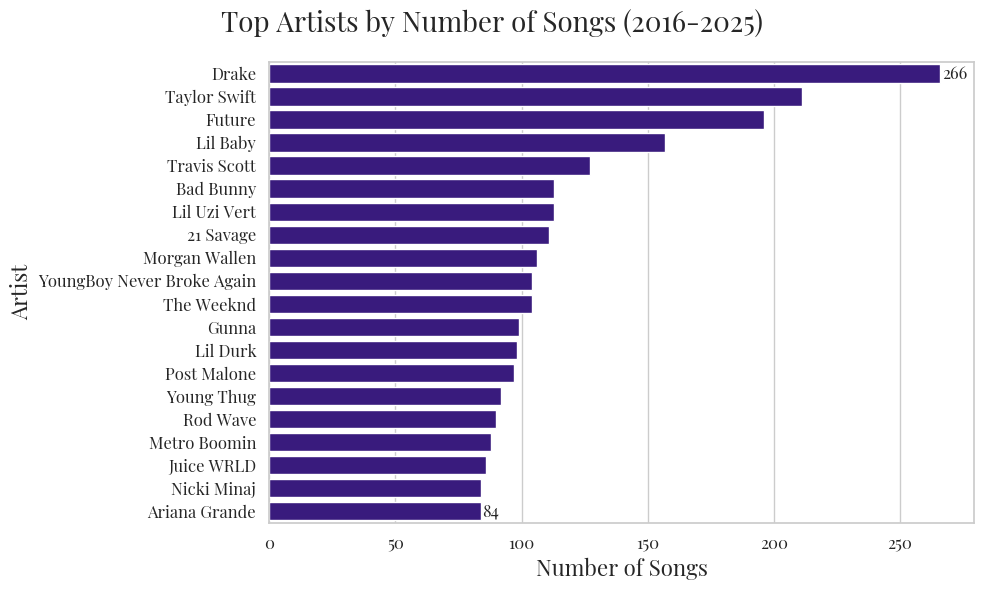

In [80]:
# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d')

max_idx = 0
min_idx = 19

for i, row in artist_counts.iterrows():
    if i == max_idx or i == min_idx:
        ax.text(
            row['num_songs'] + 0.5,
            artist_counts.index.get_loc(i),
            str(row['num_songs']),
            va='center'
        )

plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.suptitle("Top Artists by Number of Songs (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_songs_per_artist.svg', format='svg')

plt.show()

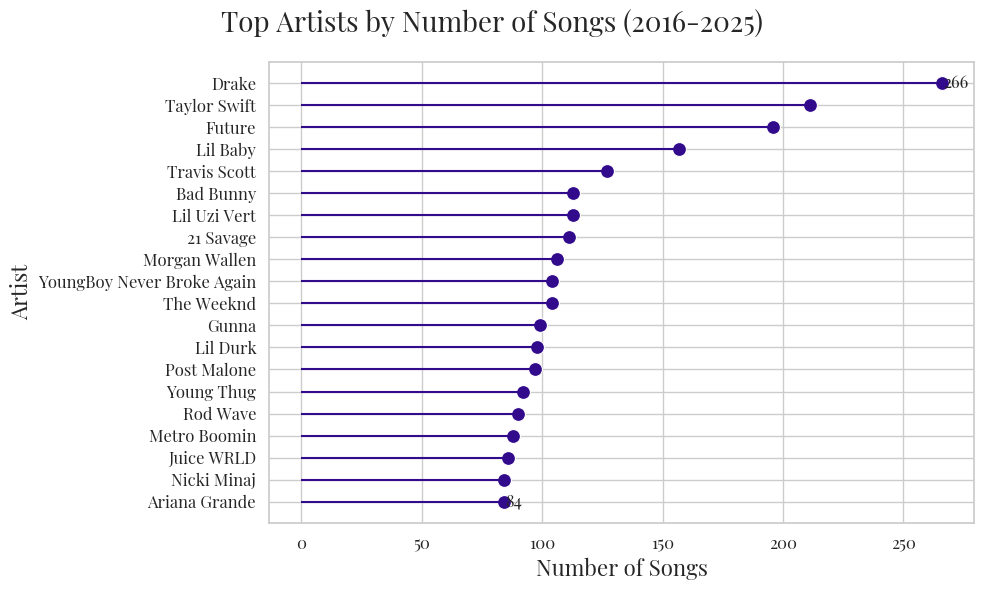

In [79]:
# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
# sns.barplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d')


ax.hlines(y=artist_counts['artist_list'],
          xmin=0,
          xmax=artist_counts['num_songs'],
          color='#320b8d')

sns.scatterplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d',
                s=100,
                ax=ax)

max_idx = 0
min_idx = 19

for i, row in artist_counts.iterrows():
    if i == max_idx or i == min_idx:
        ax.text(
            row['num_songs'] + 0.5,
            artist_counts.index.get_loc(i),
            str(row['num_songs']),
            va='center'
        )

plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.suptitle("Top Artists by Number of Songs (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
# plt.savefig('../charts/num_songs_per_artist.svg', format='svg')

plt.show()

## Max Number of Weeks on Chart per Song

In [61]:
# get unique songs
df_songs = df.copy()
df_songs = df_songs.groupby(by=['title','artist']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()
num_weeks_per_song = df_songs.sort_values(by=['weeks_in_data'], ascending=False)

In [62]:
num_weeks_per_song.head(20)

,title,artist,weeks_in_data,max_weeks_on_chart
2984,Lose Control,Teddy Swims,112,112
2134,Heat Waves,Glass Animals,91,91
621,Blinding Lights,The Weeknd,90,90
487,Beautiful Things,Benson Boone,89,89
123,A Bar Song (Tipsy),Shaboozey,77,77
2869,Levitating,Dua Lipa,77,77
5649,Wildflower,Billie Eilish,72,72
4561,Snooze,SZA,70,70
4337,Save Your Tears,The Weeknd & Ariana Grande,69,69
3924,Pink Pony Club,Chappell Roan,68,68


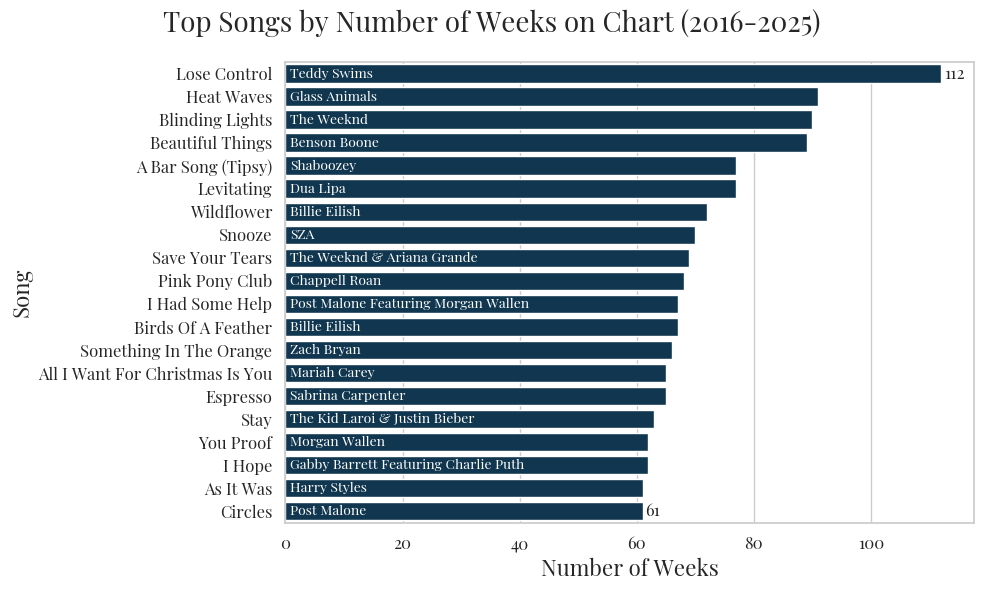

In [77]:
# keep top N songs
top_n = 20
song_counts = num_weeks_per_song.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=song_counts, x='weeks_in_data', y='title', color='#06395b')

max_idx = 0
min_idx = 19

for i, row in song_counts.iterrows():
    ax.text(
        0.75,
        song_counts.index.get_loc(i),
        str(row['artist']),
        va='center',
        color='white',
        size=10
    )
    if i == max_idx or i == min_idx:
        ax.text(
            row['weeks_in_data'] + 0.5,
            song_counts.index.get_loc(i),
            str(row['weeks_in_data']),
            va='center'
        )

plt.xlabel('Number of Weeks')
plt.ylabel('Song')
plt.suptitle("Top Songs by Number of Weeks on Chart (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_weeks_per_song.svg', format='svg')

plt.show()

## Linked View 

In [5]:
# get unique songs
df_song_rank = df.copy()
df_song_rank = (
    df_song_rank
    .sort_values('chart_date')
    .groupby(['title', 'artist'], as_index=False)
    .agg(
        weeks_in_data=('chart_date', 'count'),
        peak_position=('rank', 'min'),
        debut_rank=('rank', 'first')
    )
)

In [6]:
import altair as alt
import pandas as pd
from IPython.display import HTML

alt.data_transformers.disable_max_rows()
alt.renderers.enable('default', embed_options={'renderer': 'canvas'})

# selection object 
selection = alt.selection_point(fields=["title"], empty=False)

# scatterplot
scatter = alt.Chart(df_song_rank).mark_circle(size=60).encode(
    x=alt.X("weeks_in_data:Q", title="Number of Weeks"),
    y=alt.Y("peak_position:Q", title="Peak Position", scale=alt.Scale(reverse=True)),
    color=alt.condition(
        selection,
        alt.Color("debut_rank:Q", scale=alt.Scale(scheme="viridis")),
        alt.value("lightgray"),
    ),
    tooltip=["title", "artist", "weeks_in_data", "peak_position", "debut_rank"],
)
# ).add_params(
#     selection
# ).properties(height=350)

# # --- Curve (weekly positions) ---
# curve = alt.Chart(df_weekly).mark_line(point=True).encode(
#     x=alt.X("week_num:Q", title="Week"),
#     y=alt.Y("position:Q", title="Chart position", scale=alt.Scale(reverse=True)),
#     color=alt.Color("title:N", legend=None),
#     tooltip=["title", "artist", "week_num", "position"],
# ).transform_filter(
#     selection
# ).properties(height=250)

# label = alt.Chart(df_weekly).mark_text(
#     align="left", dx=5, fontSize=13
# ).encode(
#     x=alt.X("max(week_num):Q"),
#     y=alt.Y("min(position):Q", scale=alt.Scale(reverse=True)),
#     text="title:N",
# ).transform_filter(selection)

# combined = (scatter & (curve + label)).resolve_scale(color="independent")

# HTML(combined.to_html())
scatter

alt.Chart(...)

In [9]:
df.head()

,chart_date,rank,title,artist,weeks_on_chart,peak_position,last_position,is_new,year,artist_list
0,2016-01-02,1,Hello,Adele,8,1,1,False,2016,['Adele']
1,2016-01-02,2,Sorry,Justin Bieber,8,2,2,False,2016,['Justin Bieber']
2,2016-01-02,3,Hotline Bling,Drake,20,2,3,False,2016,['Drake']
3,2016-01-02,4,Love Yourself,Justin Bieber,5,4,5,False,2016,['Justin Bieber']
4,2016-01-02,5,What Do You Mean?,Justin Bieber,16,1,4,False,2016,['Justin Bieber']


In [8]:
default_song = df_song_rank.sort_values("weeks_in_data", ascending=False).iloc[0]
default_song

title            Lose Control
artist            Teddy Swims
weeks_in_data             112
peak_position               1
debut_rank                 99
Name: 2984, dtype: object

In [7]:
print(alt.__version__)

6.0.0


## Flash vs Burn categorization

In [ ]:
def categorize_songs(df):
    """
    df with columns: title, artist, chart_date, rank
    Returns a dataframe with one row per song + category columns
    """

    songs = []

    for (artist, title), group in df.groupby(['artist', 'title']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = len(g)

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        peak_week = g['rank'].idxmin()

        # skip songs only on chart for one week
        if total_weeks < 2:
            songs.append({
            'artist': artist,
            'title': title,
            'total_weeks': total_weeks,
            'peak_rank': peak_rank,
            'debut_rank': debut_rank,
            'weeks_to_peak': 0,
            'rise_rate': 0,
            'decay_rate': ,
            'high_debut': high_debut,
        })

        # rise rate 
        weeks_to_peak = peak_week 
        rise_rate = weeks_to_peak / total_weeks

        # decay rate

        # after peak data  
        post_peak = g.iloc[peak_week:]

        if len(post_peak) < 2:
            # if it peaked on last week = fast drop = high decay rate
            decay_rate = 999
        else:
            # average rank change per week after peak
            # positive = falling down the chart (rank number increasing)
            rank_changes = post_peak['rank'].diff().dropna()
            decay_rate = rank_changes.mean()

        # debut position
        high_debut = debut_rank <= 50

        songs.append({
            'artist': artist,
            'title': title,
            'total_weeks': total_weeks,
            'peak_rank': peak_rank,
            'debut_rank': debut_rank,
            'weeks_to_peak': weeks_to_peak,
            'rise_rate': rise_rate,
            'decay_rate': decay_rate,
            'high_debut': high_debut,
        })

    stats = pd.DataFrame(songs)

    # thresholds
    fast_decay_threshold = stats['decay_rate'].quantile(0.50)   # top 50% fastest drops
    slow_rise_threshold = stats['rise_rate'].quantile(0.50)   # bottom 50% slowest climbers

    # function to assign category 
    def assign_category(row):
        fast_decay = row['decay_rate'] >= fast_decay_threshold
        slow_rise  = row['rise_rate'] <= slow_rise_threshold

        if not slow_rise and fast_decay:
            return 'flash'        # rose quickly, fell fast
        elif slow_rise and not fast_decay:
            return 'slow_burn'     # climbed slowly, stayed long
        elif not slow_rise and not fast_decay:
            return 'hit'     # rose quickly, held position
        else:
            return 'sleeper'       # climbed slowly, fell fast

    stats['category'] = stats.apply(assign_category, axis=1)

    return stats

rise rate 
- how many weeks did it take to reach peak from debut / total weeks on chart
- 0.0 = debuted at peak (instant), 1.0 = peaked on last week

decay rate 
- look at rank for weeks after it peaked
- average of the changes in rank after peak
- 0.0 stayed at peak, more positive = higher number of rank places dropped per week 

debut position
- did it start in the top half of the chart (rank above or equal to 50)

In [6]:
categorized_df = categorize_songs(df)

In [9]:
categorized_df.peak_rank.describe()

count    3757.000000
mean       38.445568
std        25.294980
min         1.000000
25%        17.000000
50%        36.000000
75%        57.000000
max        99.000000
Name: peak_rank, dtype: float64

In [10]:
categorized_df.total_weeks.describe()

count    3757.000000
mean       13.331914
std        12.218340
min         2.000000
25%         3.000000
50%        10.000000
75%        20.000000
max       112.000000
Name: total_weeks, dtype: float64

In [93]:
categorized_df.loc[categorized_df.category=='flash'].sort_values('peak_rank').head(20)

,artist,title,total_weeks,peak_rank,debut_rank,weeks_to_peak,rise_rate,decay_rate,high_debut,category
318,Beyonce,Break My Soul,18,1,15,6,0.333333,7.909091,True,flash
421,Bobby Helms,Jingle Bell Rock,51,2,47,50,0.980392,999.000000,True,flash
2812,Prince And The Revolution,Purple Rain,2,4,17,1,0.500000,999.000000,True,flash
2506,"Nat ""King"" Cole",The Christmas Song (Merry Christmas To You),48,6,38,47,0.979167,999.000000,True,flash
888,Drake,I'm Upset,16,7,19,5,0.312500,9.000000,True,flash
1767,Kelly Clarkson,Underneath The Tree,35,7,44,34,0.971429,999.000000,True,flash
2809,Prince,When Doves Cry,2,8,20,1,0.500000,999.000000,True,flash
1620,Juice WRLD X Halsey,Life's A Mess,6,9,74,1,0.166667,22.000000,False,flash
3537,"Tyler, The Creator",Noid,5,10,43,1,0.200000,24.666667,True,flash
2333,Michael Jackson,Thriller,9,10,31,8,0.888889,999.000000,True,flash


In [94]:
categorized_df.loc[categorized_df.category=='slow_burn'].sort_values('peak_rank').head(20)

,artist,title,total_weeks,peak_rank,debut_rank,weeks_to_peak,rise_rate,decay_rate,high_debut,category
3723,Zach Bryan Featuring Kacey Musgraves,I Remember Everything,52,1,1,0,0.000000,0.392157,True,slow_burn
131,Ariana Grande,7 Rings,33,1,1,0,0.000000,1.218750,True,slow_burn
160,Ariana Grande,"Thank U, Next",28,1,1,0,0.000000,1.777778,True,slow_burn
157,Ariana Grande,Positions,29,1,1,0,0.000000,1.285714,True,slow_burn
204,BTS,Butter,20,1,1,0,0.000000,3.000000,True,slow_burn
206,BTS,Dynamite,32,1,1,0,0.000000,0.935484,True,slow_burn
3339,The Kid Laroi & Justin Bieber,Stay,63,1,3,3,0.047619,0.372881,True,slow_burn
3360,The Weeknd,Heartless,23,1,32,1,0.043478,1.714286,True,slow_burn
1792,Kendrick Lamar,Not Like Us,53,1,1,0,0.000000,0.423077,True,slow_burn
1796,Kendrick Lamar,Squabble Up,30,1,1,0,0.000000,1.655172,True,slow_burn


In [91]:
categorized_df.rise_rate.describe()

count    3757.000000
mean        0.241056
std         0.283839
min         0.000000
25%         0.000000
50%         0.076923
75%         0.500000
max         0.980392
Name: rise_rate, dtype: float64

In [92]:
categorized_df.decay_rate.describe()

count    3757.000000
mean       57.398546
std       204.329699
min         0.000000
25%         2.941176
50%         7.000000
75%        21.333333
max       999.000000
Name: decay_rate, dtype: float64